Custom FrozenLake Map:
SFFF
FHFH
FFHF
HFFG

Number of States: 16
Number of Actions: 4

Initial Q-table:
[[0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]]

Initial State-Value Function:
[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]

Final Q-table:
[[0.184 0.128 0.126 0.134]
 [0.075 0.086 0.065 0.132]
 [0.068 0.065 0.061 0.097]
 [0.046 0.051 0.037 0.088]
 [0.193 0.126 0.092 0.122]
 [0.5   0.5   0.5   0.5  ]
 [0.003 0.001 0.025 0.004]
 [0.5   0.5   0.5   0.5  ]
 [0.102 0.187 0.135 0.227]
 [0.127 0.194 0.099 0.087]
 [0.5   0.5   0.5   0.5  ]
 [0.5   0.5   0.5   0.5  ]
 [0.5   0.5   0.5   0.5  ]
 [0.253 0.312 0.571 0.288]
 [0.3   0.759 0.522 0.603]
 [0.5   0.5   0.5   0.5  ]]

Estimated State-Value Function:
[[0.184 0.13

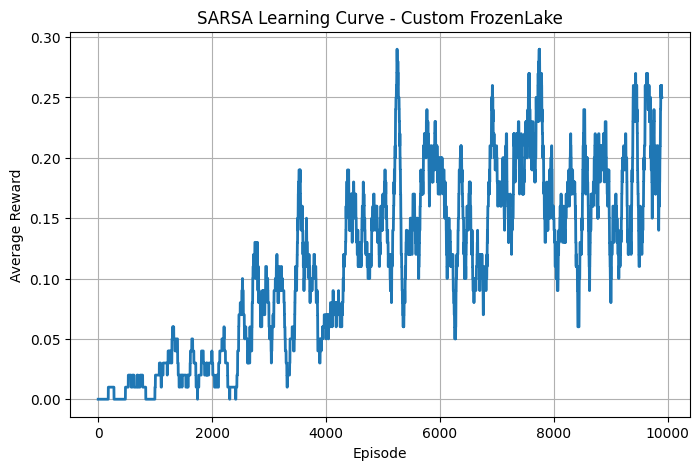

In [1]:
!pip install gymnasium

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


# -------------------------------------------------
# Create Custom FrozenLake Environment
# -------------------------------------------------

custom_map = [
    "SFFF",
    "FHFH",
    "FFHF",
    "HFFG"
]

env = gym.make(
    "FrozenLake-v1",
    desc=custom_map,
    is_slippery=True
)

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Custom FrozenLake Map:")

for row in custom_map:
    print(row)

print("\nNumber of States:", n_states)
print("Number of Actions:", n_actions)


# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 10000
max_steps_per_episode = 100

alpha = 0.1          # Learning rate
gamma = 0.99         # Discount factor

epsilon = 1.0        # Initial exploration rate
epsilon_min = 0.05
epsilon_decay = 0.9995


# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

initial_value = 0.5

Q = np.full(
    (n_states, n_actions),
    initial_value,
    dtype=float
)

print("\nInitial Q-table:")
print(Q)

print("\nInitial State-Value Function:")
print(np.max(Q, axis=1))


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):
    """
    Selects an action using epsilon-greedy strategy.
    """

    # Exploration
    if np.random.random() < epsilon:
        return env.action_space.sample()

    # Exploitation
    max_q = np.max(Q[state])

    # Select randomly among equally good actions
    best_actions = np.flatnonzero(
        Q[state] == max_q
    )

    return np.random.choice(best_actions)


# -------------------------------------------------
# SARSA Training
# -------------------------------------------------

episode_rewards = []

for episode in range(num_episodes):

    # Reset environment
    state, info = env.reset()

    # Select initial action
    action = epsilon_greedy_action(
        state,
        epsilon
    )

    total_reward = 0

    for step in range(max_steps_per_episode):

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        # -------------------------------------------------
        # Terminal State
        # -------------------------------------------------

        if terminated or truncated:

            # For terminal states:
            # Q(s,a) <- Q(s,a) + alpha[R - Q(s,a)]

            td_target = reward

            td_error = (
                td_target
                - Q[state, action]
            )

            Q[state, action] += (
                alpha * td_error
            )

            break

        # -------------------------------------------------
        # Select Next Action
        # -------------------------------------------------

        next_action = epsilon_greedy_action(
            next_state,
            epsilon
        )

        # -------------------------------------------------
        # SARSA Update
        # -------------------------------------------------

        td_target = (
            reward
            + gamma * Q[next_state, next_action]
        )

        td_error = (
            td_target
            - Q[state, action]
        )

        Q[state, action] += (
            alpha * td_error
        )

        # Move to next state and action
        state = next_state
        action = next_action

    # Store episode reward
    episode_rewards.append(total_reward)

    # -------------------------------------------------
    # Variable Epsilon Decay
    # -------------------------------------------------

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )


# -------------------------------------------------
# Extract State Values and Learned Policy
# -------------------------------------------------

state_values = np.max(
    Q,
    axis=1
)

learned_policy = np.argmax(
    Q,
    axis=1
)


# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):

    print("\nEstimated State-Value Function:")

    print(
        np.round(
            values.reshape(4, 4),
            3
        )
    )


def print_policy(policy):

    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [
            action_symbols[action]
            for action in policy
        ]
    ).reshape(4, 4)

    print("\nLearned Policy:")

    print(policy_grid)


# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")

print(
    np.round(
        Q,
        3
    )
)

print_value_function(
    state_values
)

print_policy(
    learned_policy
)


# -------------------------------------------------
# Average Reward
# -------------------------------------------------

average_reward = np.mean(
    episode_rewards[-1000:]
)

print(
    "\nAverage reward over last 1000 episodes:",
    round(average_reward, 4)
)

print(
    "Final Epsilon:",
    round(epsilon, 4)
)


# -------------------------------------------------
# Plot SARSA Learning Curve
# -------------------------------------------------

window = 100

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    moving_average,
    linewidth=2
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Average Reward"
)

plt.title(
    "SARSA Learning Curve - Custom FrozenLake"
)

plt.grid(
    True
)

plt.show()


# -------------------------------------------------
# Close Environment
# -------------------------------------------------

env.close()